# Temporal Patterns
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary

In this notebook, we ask **when** street flooding happens in New York City. Answering that well is mostly about deciding *what to count* and *what to divide by*, so the first half of the notebook sets up those choices before any seasonal or time-of-day results.

Throughout, **"What not to do"** notes point out tempting analyses that give misleading answers with this data.

1. **Timestamps and Time Zones**
   - 1.1 Converting to Local Time
   - 1.2 Checking the Conversion Against Hurricane Ida

---

2. **Choosing What to Count**
   - 2.1 Two Flooding Mechanisms: Tidal and Rain-Driven
   - 2.2 Not Every Flood Event Is a Flood
   - 2.3 One Storm, Many Events: Rain Episodes

---

3. **Why Raw Counts Can Mislead**
   - 3.1 The Network Grew
   - 3.2 Comparing Sensors: Totals vs. Rates
   - 3.3 Sensors Are Not Interchangeable
   - 3.4 Small Denominators and Uncertainty

---

4. **Seasonality**
   - 4.1 Year-by-Month Grid
   - 4.2 What Not to Do: A Pooled Calendar-Month Chart

---

5. **Time of Day**
   - 5.1 Counting Episodes, Not Events

---

6. **Widespread Rain Episodes**
   - 6.1 Ranking Episodes with Uncertainty
   - 6.2 Matching Episodes to Named Storms

---

7. **What This Notebook Can't Tell You (and What Would)**

# Import Libraries

In [111]:
# libraries
# Standard library
import json
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import floodnet

# series colors
colors = floodnet.COLORBLIND_PALETTE
TIDAL_COLOR = colors[4]      # cyan
NON_TIDAL_COLOR = colors[0]  # blue

In [112]:
# print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "numpy": np.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
numpy      2.4.2


In [113]:
# sanity check Manifest file
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
print(json.dumps(manifest, indent=2))

[
  {
    "dataset_id": "kb2e-tjy3",
    "name": "FloodNet: Sensor Deployment Metadata",
    "data_updated": "2026-09-15",
    "metadata_updated": null,
    "view_count": 1616,
    "download_count": 1387,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclassified"
    ],
    "update_frequency": "unknown",
    "row_count": 491,
    "column_count": 16,
    "data_url": "https://data.cityofnewyork.us/resource/kb2e-tjy3.csv",
    "downloaded_at": "2026-09-27",
    "last_checked_at": "2026-09-27",
    "latest_created_at": "2026-09-15T13:00:23.446Z",
    "previous_created_at": "2026-09-01T13:00:19.833Z"
  },
  {
    "dataset_id": "aq7i-eu5q",
    "name": "FloodNet: Street Flooding Events Measured by FloodNet Sensors",
    "data_updated": "2026-09-15",
    "metadata_updated": null,
    "view_count": 3944,
    "download_count": 1567,
    "comment_count": 0,
    "average_rating": 0,
    "category": "Environment",
    "tags": [
      "unclass

Note: The manifest captures dataset metadata at the time of download. Since NYC Open Data datasets are updated periodically, results may differ over time. For the latest version, review the dataset page on NYC Open Data or rerun the data download notebook.

To review how we downloaded these datasets from NYC Open Data, please refer to the notebook [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb).

# Load and Inspect Data
For a more robust approach to inspecting the data, please refer to notebook [01-load-inspect.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/01-load-inspect.ipynb).

In [114]:
# 1) read in flood sensor deployments as dataframe
metadata_path = "data/sensor-metadata.csv"
metadata_df = pl.read_csv(metadata_path, try_parse_dates=True)

# inspect the shape of the data
n_rows, n_columns = metadata_df.shape
print("Metadata shape:")
print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

# 2) read in flood events as dataframe
events_path = "data/flood-events.csv"
events_df = pl.read_csv(
    events_path,
    # some columns have sparce data, need to expand the row count
    infer_schema_length=100000,
    try_parse_dates=True
)

# inspect the shape of the data
n_rows, n_columns = events_df.shape

print("\nFlood Events shape:")
print(f"Number of rows: {n_rows:,}")
print(f"Number of columns: {n_columns}")

Metadata shape:
Number of rows: 491
Number of columns: 16

Flood Events shape:
Number of rows: 3,269
Number of columns: 13


# Join Sensor Metadata and Flood Events Datasets

In [115]:
# merge flood sensor events with sensor metadata
merged_df = events_df.join(
    metadata_df.drop("sensor_name"),
    on="sensor_id",
    how="left",  # keep all events, even if metadata is missing
)

# inspect the shape of the merged data
n_rows, n_columns = merged_df.shape
print(f"Number of rows of merged df: {n_rows:,}")
print(f"Number of columns: {n_columns}")

# events without matching metadata
missing_meta_count = merged_df["tidally_influenced"].null_count()
print(f"Events without matching sensor metadata: {missing_meta_count}")

Number of rows of merged df: 3,269
Number of columns: 27
Events without matching sensor metadata: 0


# 1) Timestamps and Time Zones
## 1.1 Converting to Local Time
The timestamps in both datasets have no time zone attached (e.g., `2023-10-30T12:00:39.000`). As in the other notebooks in this series, we treat them as **UTC** and convert them to New York City local time (`America/New_York`), which also handles daylight saving time.

This matters much more here than in the rankings notebook. Every time-of-day result depends on it: reading UTC as local time would shift each event by 4 hours (summer, EDT) or 5 hours (winter, EST).

In [116]:
merged_df = merged_df.with_columns(
    # assign timezone to UTC, then convert to NYC local time
    pl.col("flood_start_time")
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("flood_start_time_et"),
    pl.col("flood_end_time")
        .dt.replace_time_zone("UTC")
        .dt.convert_time_zone("America/New_York")
        .alias("flood_end_time_et"),
)

# calendar fields used throughout this notebook (all in local time)
merged_df = merged_df.with_columns(
    pl.col("flood_start_time_et").dt.date().alias("flood_date"),
    pl.col("flood_start_time_et").dt.truncate("1mo").dt.date().alias("month_start"),
    pl.col("flood_start_time_et").dt.hour().alias("start_hour"),
)

# preview the same event in UTC and local time
merged_df.select(
    "flood_start_time", "flood_start_time_et",
    "flood_date", "month_start", "start_hour"
).head()

flood_start_time,flood_start_time_et,flood_date,month_start,start_hour
datetime[μs],"datetime[μs, America/New_York]",date,date,i8
2023-10-30 12:00:39,2023-10-30 08:00:39 EDT,2023-10-30,2023-10-01,8
2025-04-26 23:17:20,2025-04-26 19:17:20 EDT,2025-04-26,2025-04-01,19
2024-02-09 11:41:01,2024-02-09 06:41:01 EST,2024-02-09,2024-02-01,6
2025-08-20 21:05:19,2025-08-20 17:05:19 EDT,2025-08-20,2025-08-01,17
2024-01-10 00:39:25,2024-01-09 19:39:25 EST,2024-01-09,2024-01-01,19


## 1.2 Checking the Conversion Against Hurricane Ida
An assumption this important should be checked against something we know independently. The remnants of Hurricane Ida brought record rainfall to NYC on the evening of **September 1, 2021**: Central Park recorded 3.15 inches of rain in a single hour ending around 9:50 pm EDT.

If our conversion is right, the flood events from Ida should begin that evening.

In [117]:
merged_df.filter(
    pl.col("flood_start_time_et").dt.date().is_between(
        pl.date(2021, 9, 1), pl.date(2021, 9, 2)
    )
).select(
    "sensor_name", "flood_start_time", "flood_start_time_et", "max_depth_inches"
).sort("flood_start_time_et")

sensor_name,flood_start_time,flood_start_time_et,max_depth_inches
str,datetime[μs],"datetime[μs, America/New_York]",f64
"""BK - 9th St/Smith St""",2021-09-02 00:11:58,2021-09-01 20:11:58 EDT,27.76
"""BK - Hoyt St/5th St""",2021-09-02 01:24:41,2021-09-01 21:24:41 EDT,10.35
"""BK - Carroll St/4th Av""",2021-09-02 01:27:16,2021-09-01 21:27:16 EDT,35.59
"""Q - Russell St 2""",2021-09-02 01:51:03,2021-09-01 21:51:03 EDT,2.87
"""Q - Russell St 1""",2021-09-02 02:03:01,2021-09-01 22:03:01 EDT,1.5


In local time, the Ida flood events begin between about 8 pm and 10 pm on September 1, right when the heaviest rain fell. If the raw timestamps were already local time, the flooding would appear to start after midnight, *after* the worst of the rain. The UTC assumption checks out.

## Choosing the Analysis Window
The most recent month is usually only partly recorded, which would make it look artificially quiet. We keep only **complete months**, from the first month with a flood event through the month before the latest event.

In [118]:
first_month = merged_df["month_start"].min()
latest_month = merged_df["month_start"].max()

# the window ends where the (partial) latest month begins
window_end = latest_month
events_window_df = merged_df.filter(pl.col("month_start") < window_end)

# every month in the window
months = pl.date_range(
    first_month,
    window_end,
    interval="1mo",
    closed="left",
    eager=True,
).alias("month_start")

print(f"Analysis window: {months.min()} to {months.max()} ({len(months)} months)")
print(f"Events in window: {events_window_df.height:,} of {merged_df.height:,}")

Analysis window: 2020-11-01 to 2026-08-01 (70 months)
Events in window: 3,219 of 3,269


# 2) Choosing What to Count
Before counting anything, we make three decisions: **which sensors** to group together, **which events** count as flooding, and **what counts as one storm**.

## 2.1 Two Flooding Mechanisms: Tidal and Rain-Driven
Tidally influenced sensors flood mostly from high tides and coastal surge; non-tidal sensors flood mostly from rainfall overwhelming the drainage system. These are different physical processes, driven by the moon and the ocean on one hand and by the weather on the other. Let's see how much of the dataset each group accounts for.

In [119]:
mechanism_df = (
    events_window_df
    .group_by("tidally_influenced")
    .agg(
        pl.col("sensor_id").n_unique().alias("sensors_with_events"),
        pl.len().alias("events"),
        pl.col("duration_mins").sum().alias("flood_minutes"),
    )
    .join(
        metadata_df.group_by("tidally_influenced").agg(pl.len().alias("sensors")),
        on="tidally_influenced",
    )
    .with_columns(
        (pl.col(c) / pl.col(c).sum() * 100).round(1).alias(f"pct_{c}")
        for c in ["sensors", "events", "flood_minutes"]
    )
    .select("tidally_influenced", "sensors", "pct_sensors", "pct_events", "pct_flood_minutes")
)

mechanism_df

tidally_influenced,sensors,pct_sensors,pct_events,pct_flood_minutes
str,u32,f64,f64,f64
"""No""",427,87.0,34.2,21.5
"""Yes""",64,13.0,65.8,78.5


In [120]:
# how concentrated are events in a few sensors?
sensor_counts_df = (
    events_window_df
    .group_by("sensor_name", "tidally_influenced")
    .agg(pl.len().alias("events"))
    .sort("events", descending=True)
    .with_columns(
        (pl.col("events") / pl.col("events").sum() * 100).round(1).alias("pct_of_all_events")
    )
)

top_5_share = sensor_counts_df["pct_of_all_events"].head(5).sum()
print(f"The top 5 sensors account for {top_5_share:.1f}% of all flood events\n")
sensor_counts_df.head(5)

The top 5 sensors account for 36.5% of all flood events



sensor_name,tidally_influenced,events,pct_of_all_events
str,str,u32,f64
"""Q - Beach 84 St""","""Yes""",452,14.0
"""BX - Ditmars St/Hunter Ave 2""","""Yes""",362,11.2
"""Q - Russell St 1""","""Yes""",148,4.6
"""Q - Brookville Blvd/ Snake Rd …","""Yes""",118,3.7
"""Q - Beach 84 St (2)""","""Yes""",98,3.0


A small group of tidal sensors produces most of the events and most of the flooded minutes. A handful of coastal sites record flooding with nearly every high tide.

**What not to do:** pool tidal and non-tidal sensors into one "all sensors" statistic. Any citywide total or average would mostly describe a few coastal sites, and it would mix two different causes of flooding.

**Decision:** we analyze the two groups separately. Studying tidal flooding properly requires tide data (see section 7), so **from here on this notebook focuses on non-tidal, rain-driven flooding.**

In [121]:
rain_events_df = events_window_df.filter(pl.col("tidally_influenced") == "No")
rain_sensors_df = metadata_df.filter(pl.col("tidally_influenced") == "No")

print(f"Non-tidal flood events: {rain_events_df.height:,}")
print(f"Non-tidal sensors: {rain_sensors_df.height:,}")

Non-tidal flood events: 1,100
Non-tidal sensors: 427


## 2.2 Not Every Flood Event Is a Flood
FloodNet defines a flood event as water deeper than **10 mm** (about 0.4 inches). That's a sensitive threshold, which is great for detection. But it means many events are shallow ponding that a driver or pedestrian might barely notice.

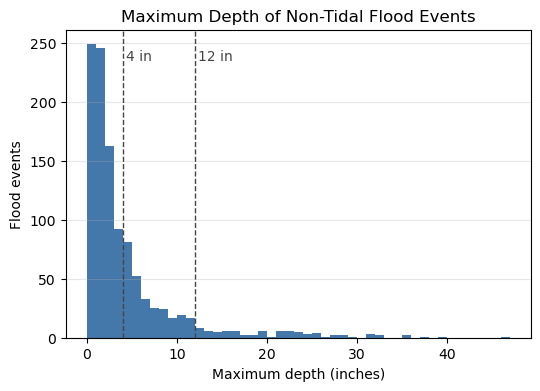

Median maximum depth: 2.3 in
Events under 4 in: 68%
Events of 12 in or more: 7%


In [122]:
DEPTH_THRESHOLD_IN = 4
SEVERE_THRESHOLD_IN = 12

depths = rain_events_df["max_depth_inches"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(depths, bins=np.arange(0, depths.max() + 1, 1), color=NON_TIDAL_COLOR)
for threshold in [DEPTH_THRESHOLD_IN, SEVERE_THRESHOLD_IN]:
    ax.axvline(threshold, color="#444444", linestyle="--", linewidth=1)
    ax.text(threshold + 0.3, ax.get_ylim()[1] * 0.9, f"{threshold} in", color="#444444")
ax.set_xlabel("Maximum depth (inches)")
ax.set_ylabel("Flood events")
ax.set_title("Maximum Depth of Non-Tidal Flood Events")
ax.grid(axis="y", alpha=0.3)
plt.show()

print(f"Median maximum depth: {depths.median():.1f} in")
print(f"Events under {DEPTH_THRESHOLD_IN} in: {(depths < DEPTH_THRESHOLD_IN).mean() * 100:.0f}%")
print(f"Events of {SEVERE_THRESHOLD_IN} in or more: {(depths >= SEVERE_THRESHOLD_IN).mean() * 100:.0f}%")

About two-thirds of non-tidal events never reach 4 inches.

**What not to do:** count every event equally. A count that treats a half-inch puddle the same as two feet of water isn't measuring flood hazard.

**Decision:** for the rest of this notebook we count flooding that reaches at least **4 inches**, and use **12 inches** for severe flooding. These aren't arbitrary: they're the depth thresholds the dataset itself reports, in the `duration_above_4_inches_mins` and `duration_above_12_inches_mins` columns. The exact threshold is a judgment call. What matters is choosing one and reporting it.

## 2.3 One Storm, Many Events: Rain Episodes
During a single storm, water at one sensor can drop below the 10 mm threshold and rise again, which splits one flood into several events. Let's see how often that happens.

In [123]:
sensor_days_df = rain_events_df.group_by("sensor_id", "flood_date").agg(pl.len().alias("events"))

events_in_split_days = sensor_days_df.filter(pl.col("events") > 1)["events"].sum()
print(
    f"{events_in_split_days / rain_events_df.height * 100:.0f}% of non-tidal events "
    "share a sensor and a day with at least one other event"
)

27% of non-tidal events share a sensor and a day with at least one other event


**What not to do:** treat each event as an independent flood. When a storm splits a flood into pieces, the event count goes up even though the street flooded once.

**Decision:** we group events into **rain episodes**, stretches of time when flooding is happening somewhere in the non-tidal network:

1. Sort the non-tidal flood events by start time.
2. Walk through them in order. If an event starts within 6 hours of the end of the flooding before it, it joins the current episode. Otherwise, it starts a new one.

The 6-hour gap follows the same idea as the dry period hydrologists commonly use to separate one rainstorm from the next.

**What not to do:** build episodes from *all* sensors. Tidal sites flood with high tides roughly every 12 hours, which can chain two unrelated rainstorms into one long "episode". That's another reason we set tidal sensors aside in 2.1.

Then we collapse each episode down to **one row per sensor** (a *sensor-episode*) and keep that sensor's deepest reading. From here on, our basic unit is: **did this sensor flood to at least 4 inches during this episode?**

In [124]:
EPISODE_GAP_HOURS = 6

rain_events_df = (
    rain_events_df
    .sort("flood_start_time_et")
    # latest end time of any earlier event
    .with_columns(
        pl.col("flood_end_time_et").cum_max().shift(1).alias("latest_end_so_far")
    )
    # start a new episode after a gap longer than EPISODE_GAP_HOURS
    .with_columns(
        (
            (pl.col("flood_start_time_et") - pl.col("latest_end_so_far"))
            > pl.duration(hours=EPISODE_GAP_HOURS)
        )
        .fill_null(True)
        .cum_sum()
        .alias("episode_id")
    )
)

# one row per sensor per episode, keeping its deepest reading
sensor_episodes_df = (
    rain_events_df
    .group_by("episode_id", "sensor_id")
    .agg(
        pl.col("flood_start_time_et").min().alias("start_time"),
        pl.col("max_depth_inches").max().alias("max_depth_inches"),
    )
    .with_columns(
        pl.col("start_time").dt.truncate("1mo").dt.date().alias("month_start"),
        (pl.col("max_depth_inches") >= DEPTH_THRESHOLD_IN).alias("reached_4in"),
        (pl.col("max_depth_inches") >= SEVERE_THRESHOLD_IN).alias("reached_12in"),
    )
)

# one row per episode
episodes_df = (
    rain_events_df
    .group_by("episode_id")
    .agg(
        pl.col("flood_start_time_et").min().alias("episode_start"),
        pl.col("flood_end_time_et").max().alias("episode_end"),
    )
    .join(
        sensor_episodes_df.group_by("episode_id").agg(
            pl.col("reached_4in").sum().alias("sensors_4in"),
            pl.col("reached_12in").sum().alias("sensors_12in"),
        ),
        on="episode_id",
    )
    .with_columns(
        pl.col("episode_start").dt.date().alias("start_date"),
        pl.col("episode_end").dt.date().alias("end_date"),
        ((pl.col("episode_end") - pl.col("episode_start")).dt.total_minutes() / 60)
            .round(1)
            .alias("duration_hours"),
    )
)

print(f"Non-tidal flood events:           {rain_events_df.height:,}")
print(f"Rain episodes:                    {episodes_df.height:,}")
print(f"Sensor-episodes:                  {sensor_episodes_df.height:,}")
print(f"Sensor-episodes reaching 4 in:    {sensor_episodes_df['reached_4in'].sum():,}")
print(f"Sensor-episodes reaching 12 in:   {sensor_episodes_df['reached_12in'].sum():,}")
print(f"Episodes with any sensor at 4 in: {episodes_df.filter(pl.col('sensors_4in') > 0).height:,}")

Non-tidal flood events:           1,100
Rain episodes:                    157
Sensor-episodes:                  914
Sensor-episodes reaching 4 in:    343
Sensor-episodes reaching 12 in:   81
Episodes with any sensor at 4 in: 60


Over a thousand events become a much smaller set of sensor-episodes that reached 4 inches, spread across a few dozen rain episodes. That smaller number is a more honest picture of how much meaningful flooding the record contains, and a reminder of how little data we have for the questions that follow.

The 6-hour rule is a judgment call, and every count below rests on it. [06-rain-episodes.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/06-rain-episodes.ipynb) checks it: a storm walked through event by event, why the rule compares against `cum_max` rather than the previous row, and whether the results change when the threshold does.

# 3) Why Raw Counts Can Mislead
A raw count, like "this month had 50 floods", mixes together two different things:

1. **How often streets flood.** This is what we want to know.
2. **How long, and with how many sensors, we were watching.** This comes from how the network was built, not from how often streets flood.

## 3.1 The Network Grew
We count a sensor as **active** in a month if it was installed on or before the last day of that month and not removed before the first day.

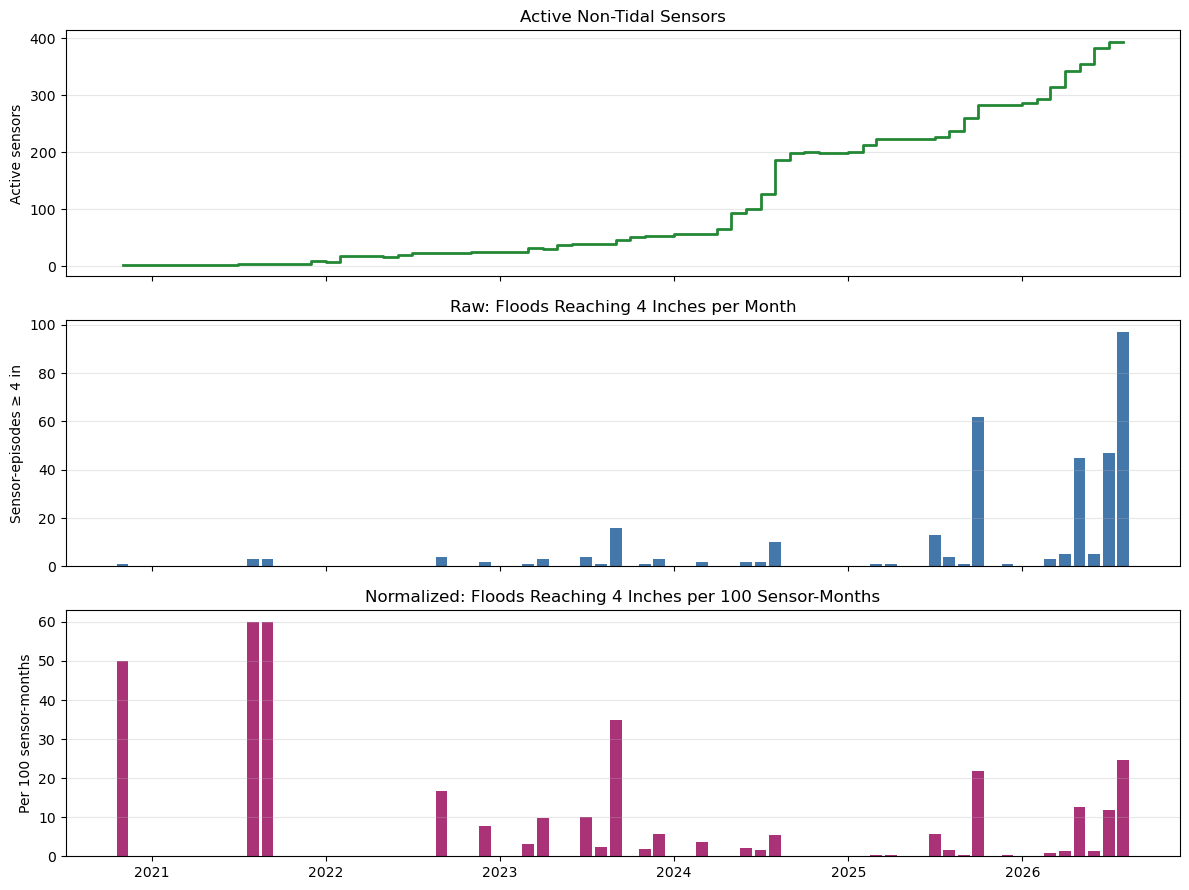

In [125]:
# one row per non-tidal sensor per month (a "sensor-month")
sensor_months_df = (
    rain_sensors_df.select(
        "sensor_id",
        "borough",
        pl.col("date_installed").dt.date(),
        pl.col("date_removed").dt.date(),
    )
    .join(pl.DataFrame(months), how="cross")
    .with_columns(pl.col("month_start").dt.month_end().alias("month_end"))
    .filter(
        (pl.col("date_installed") <= pl.col("month_end"))
        & (
            pl.col("date_removed").is_null()
            | (pl.col("date_removed") >= pl.col("month_start"))
        )
    )
)

monthly_df = (
    pl.DataFrame(months)
    .join(
        sensor_months_df.group_by("month_start").agg(pl.len().alias("active_sensors")),
        on="month_start",
        how="left",
    )
    .join(
        sensor_episodes_df.filter(pl.col("reached_4in"))
        .group_by("month_start").agg(pl.len().alias("floods_4in")),
        on="month_start",
        how="left",
    )
    .fill_null(0)
    .with_columns(
        (pl.col("floods_4in") / pl.col("active_sensors") * 100).alias("floods_per_100_sensor_months")
    )
    .sort("month_start")
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].step(monthly_df["month_start"], monthly_df["active_sensors"],
             where="post", color=colors[2], linewidth=2)
axes[0].set_ylabel("Active sensors")
axes[0].set_title("Active Non-Tidal Sensors")

axes[1].bar(monthly_df["month_start"], monthly_df["floods_4in"], width=25, color=NON_TIDAL_COLOR)
axes[1].set_ylabel("Sensor-episodes ≥ 4 in")
axes[1].set_title("Raw: Floods Reaching 4 Inches per Month")

axes[2].bar(monthly_df["month_start"], monthly_df["floods_per_100_sensor_months"],
            width=25, color=colors[5])
axes[2].set_ylabel("Per 100 sensor-months")
axes[2].set_title("Normalized: Floods Reaching 4 Inches per 100 Sensor-Months")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In the raw counts (middle), recent months look far worse than early ones. But the network (top) grew enormously over the same period, so more sensors were there to record floods. The normalized chart (bottom) doesn't show that upward trend.

**What not to do:** read the normalized chart as a trend either. Both charts are dominated by a few big storms, and section 3.3 explains why the per-sensor rate isn't comparable across years. This record can't tell us whether NYC flooding is getting better or worse.

## 3.2 Comparing Sensors: Totals vs. Rates
The same problem applies to individual sensors, because they were installed on different dates. A sensor deployed for five years has had five times as long to record floods as one deployed for one year.

We convert each sensor's total into **floods reaching 4 inches per year deployed**. We only rate sensors deployed for at least **180 days**: a rate built on a few weeks of data can swing wildly. For example, one storm in a sensor's first month works out to 12 floods per year.

In [126]:
MIN_DAYS_DEPLOYED = 180

sensor_stats_df = (
    rain_sensors_df.select(
        "sensor_id",
        "sensor_name",
        "borough",
        pl.col("date_installed").dt.date(),
        pl.col("date_removed").dt.date(),
    )
    .with_columns(
        (
            pl.min_horizontal(
                pl.col("date_removed").fill_null(window_end), pl.lit(window_end)
            )
            - pl.col("date_installed")
        )
        .dt.total_days()
        .alias("days_deployed")
    )
    .filter(pl.col("days_deployed") > 0)
    .join(
        sensor_episodes_df.filter(pl.col("reached_4in"))
        .group_by("sensor_id").agg(pl.len().alias("floods_4in")),
        on="sensor_id",
        how="left",
    )
    .with_columns(pl.col("floods_4in").fill_null(0))
    .with_columns(
        (pl.col("floods_4in") / pl.col("days_deployed") * 365.25).round(2).alias("floods_per_year"),
        pl.col("floods_4in").rank("min", descending=True).cast(pl.Int32).alias("rank_by_total"),
    )
)

rate_ranks_df = (
    sensor_stats_df
    .filter(pl.col("days_deployed") >= MIN_DAYS_DEPLOYED)
    .with_columns(
        pl.col("floods_per_year").rank("min", descending=True).cast(pl.Int32).alias("rank_by_rate")
    )
    .select("sensor_id", "rank_by_rate")
)

sensor_stats_df.join(rate_ranks_df, on="sensor_id", how="left").sort(
    "rank_by_rate", nulls_last=True
).select(
    "rank_by_rate", "rank_by_total", "sensor_name", "borough",
    "days_deployed", "floods_4in", "floods_per_year",
).head(10)

rank_by_rate,rank_by_total,sensor_name,borough,days_deployed,floods_4in,floods_per_year
i32,i32,str,str,i64,u32,f64
1,2,"""Q - 155th Ave/79th St""","""Queens""",739,10,4.94
2,15,"""Q - Bell Blvd / Northern Blvd""","""Queens""",355,4,4.12
2,15,"""Q - 56th Ave/ Springfield Blvd""","""Queens""",355,4,4.12
4,5,"""BK - Neptune Ave W 35th St""","""Brooklyn""",803,8,3.64
5,27,"""Q - Woodhull Ave/ 193rd St""","""Queens""",319,3,3.43
5,27,"""Q - 204th St/ 100th Ave""","""Queens""",319,3,3.43
5,27,"""Q - Liberty Ave/ 183rd St""","""Queens""",319,3,3.43
8,45,"""BK - Brooklyn Ave/St Johns Pl""","""Brooklyn""",222,2,3.29
9,27,"""Q - 192nd St/ 39th Ave""","""Queens""",355,3,3.09


Compare `rank_by_rate` with `rank_by_total`. Some sensors move a long way once deployment time is accounted for. Ranking by total rewards sensors for being installed early, not for flooding often.

## 3.3 Sensors Are Not Interchangeable
Dividing by sensor-months quietly assumes that every sensor-month is equivalent, as if sensors were placed at random. They weren't. Here's where the non-tidal sensors were installed each year.

In [127]:
(
    rain_sensors_df
    .with_columns(pl.col("date_installed").dt.year().alias("year_installed"))
    .group_by("year_installed", "borough")
    .agg(pl.len().alias("sensors"))
    .pivot(on="borough", index="year_installed", values="sensors", sort_columns=True)
    .fill_null(0)
    .sort("year_installed")
)

year_installed,Bronx,Brooklyn,Manhattan,Queens,Staten Island
i32,u32,u32,u32,u32,u32
2020,0,2,0,0,0
2021,0,4,3,0,0
2022,4,6,2,4,3
2023,0,19,1,12,1
2024,18,49,23,51,9
2025,32,25,15,23,6
2026,12,48,8,38,9


The early network was a handful of sensors in just one or two boroughs. It then expanded across the city to new locations, with different drainage, topography and flood history. So when the per-sensor rate changes over time, part of that change comes from **which places were being watched**, not from any change in the flooding itself.

There's a second, hidden gap: "active" here means between the install and removal dates. The metadata doesn't record outages, like a dead battery or a sensor down for maintenance. Our sensor-month counts assume every installed sensor was watching the whole time, which overstates the time we actually had eyes on the street.

**What not to do:** compare per-sensor rates from 2021 with those from 2026 as if they measured the same thing.

## 3.4 Small Denominators and Uncertainty
When only a few sensors are running, rates are very uncertain. If 3 out of 5 sensors flooded during a storm, that's 60%. But with so few sensors, the "true" share could plausibly be much lower or higher.

A **confidence interval** puts a number on that uncertainty. For a share like "3 of 5 sensors", the [Wilson score interval](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval#Wilson_score_interval) is a standard choice that behaves well even for small counts.

In [128]:
def wilson_interval(k, n, z=1.96):
    """95% Wilson score interval for k successes out of n (returns percentages)."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (center - half) * 100, (center + half) * 100


for k, n in [(3, 5), (60, 300)]:
    low, high = wilson_interval(k, n)
    print(f"{k:>3} of {n:<3} sensors = {k / n * 100:.0f}%   (95% interval: {low:.0f}% to {high:.0f}%)")

  3 of 5   sensors = 60%   (95% interval: 23% to 88%)
 60 of 300 sensors = 20%   (95% interval: 16% to 25%)


With 5 sensors, the interval covers most of the possible range. With 300 sensors, it's much narrower. We'll use this in section 6 to rank storms fairly.

# 4) Seasonality
## 4.1 Year-by-Month Grid
Which time of year floods most? Rather than pooling every January together straight away, we first lay the record out as a **year × month grid**. Each cell shows floods reaching 4 inches per 100 active non-tidal sensor-months, and the number in the cell is the raw count of sensor-episodes. Gray cells had no active non-tidal sensors.

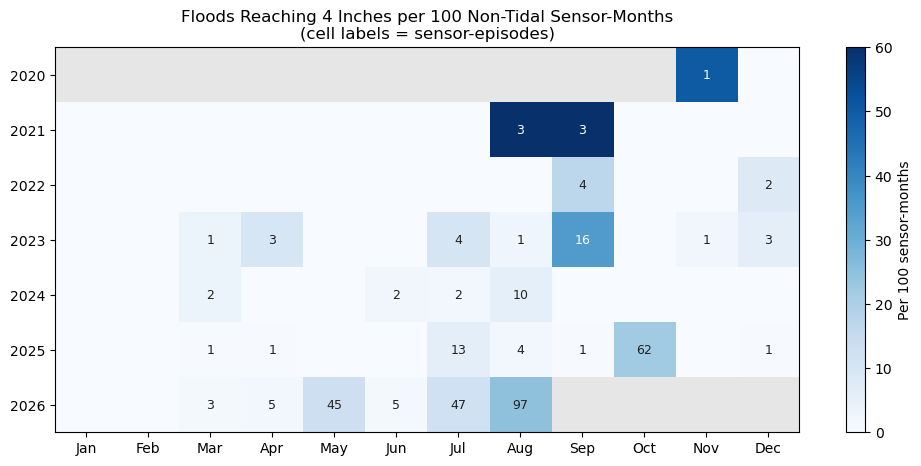

In [129]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

grid_df = monthly_df.with_columns(
    pl.col("month_start").dt.year().alias("year"),
    pl.col("month_start").dt.month().alias("month"),
)
years = list(range(grid_df["year"].min(), grid_df["year"].max() + 1))

rates = np.full((len(years), 12), np.nan)
counts = np.zeros((len(years), 12), dtype=int)
for row in grid_df.iter_rows(named=True):
    if row["active_sensors"] > 0:
        rates[years.index(row["year"]), row["month"] - 1] = row["floods_per_100_sensor_months"]
        counts[years.index(row["year"]), row["month"] - 1] = row["floods_4in"]

# sequential: one hue, light to dark; gray for "no sensors"
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#E6E6E6")

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(np.ma.masked_invalid(rates), cmap=cmap, aspect="auto")
vmax = np.nanmax(rates)
for i in range(len(years)):
    for j in range(12):
        if counts[i, j] > 0:
            ax.text(j, i, counts[i, j], ha="center", va="center", fontsize=9,
                    color="white" if rates[i, j] > vmax * 0.5 else "#222222")
ax.set_xticks(range(12), month_labels)
ax.set_yticks(range(len(years)), years)
ax.set_title("Floods Reaching 4 Inches per 100 Non-Tidal Sensor-Months\n(cell labels = sensor-episodes)")
fig.colorbar(im, ax=ax, label="Per 100 sensor-months")
plt.show()

Three things stand out:

- **Many cells are empty or nearly so.** Many months had no flooding that reached 4 inches.
- **The busy months are usually one or two storms.** What looks like a seasonal pattern is really a short list of individual storms, each landing in whatever month it happened to hit.
- **The darkest cells are the least reliable.** The highest rates are in 2020–2021, when only a few non-tidal sensors were running. As 3.4 showed, a few sensors can produce an extreme rate from one storm. Check the cell label (the raw count) before trusting a dark cell.

## 4.2 What Not to Do: A Pooled Calendar-Month Chart
A tempting shortcut is to add up each calendar month across all years and draw 12 bars. Let's check how much of each month's total comes from its single biggest episode.

In [130]:
floods_4in_df = sensor_episodes_df.filter(pl.col("reached_4in")).with_columns(
    pl.col("start_time").dt.month().alias("month")
)

(
    floods_4in_df
    .group_by("month", "episode_id")
    .agg(pl.len().alias("floods_4in"))
    .group_by("month")
    .agg(
        pl.col("floods_4in").sum().alias("total_floods_4in"),
        pl.len().alias("episodes"),
        pl.col("floods_4in").max().alias("biggest_episode"),
    )
    .with_columns(
        (pl.col("biggest_episode") / pl.col("total_floods_4in") * 100)
        .round(0)
        .alias("pct_from_biggest_episode")
    )
    .sort("month")
)

month,total_floods_4in,episodes,biggest_episode,pct_from_biggest_episode
i8,u32,u32,u32,f64
3,7,7,1,14.0
4,9,7,3,33.0
5,45,2,44,98.0
6,7,6,2,29.0
7,66,10,40,61.0
8,115,15,43,37.0
9,24,6,11,46.0
10,62,2,61,98.0
11,2,2,1,50.0


In several months, a single episode makes up most or nearly all of the total. A pooled bar chart would show those months as "high flood season" when they really had one bad storm.

**What not to do:** present a pooled calendar-month chart from a few years of data as a seasonal pattern. A real flood climatology needs decades of record. The practical route is to pair FloodNet with a long **rainfall** record (section 7): if we know how streets respond to rain, we can use a century of rainfall data to reason about the seasons.

# 5) Time of Day
## 5.1 Counting Episodes, Not Events
When during the day does rain-driven flooding begin? The obvious approach is to count flood events by start hour. But as we saw in 2.3, one storm produces many events at once, so a single storm can make one hour look busy.

Below, the left chart counts events (what not to do). The right chart counts each rain episode **once**, by its start hour, for episodes where at least one sensor reached 4 inches.

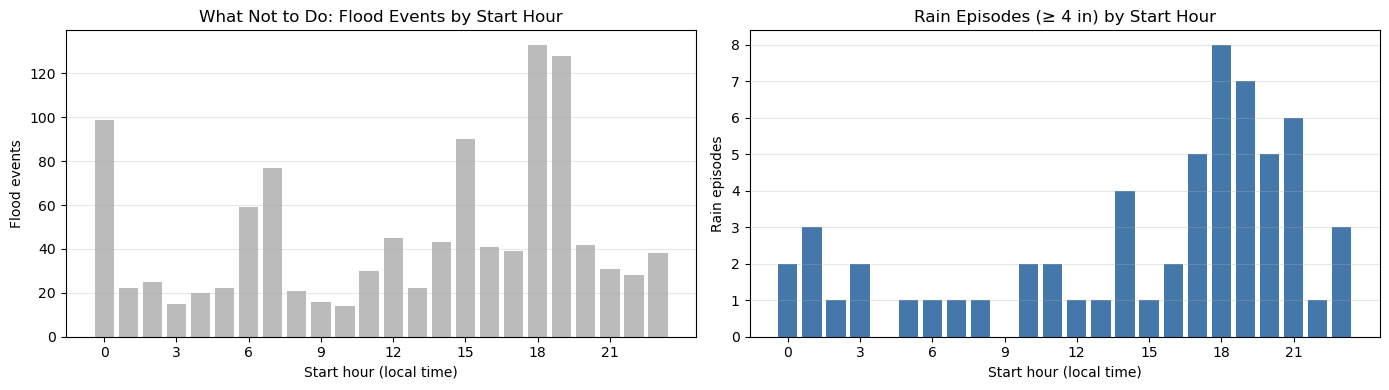

Rain episodes in the right-hand chart: 60


In [131]:
hours = pl.DataFrame({"start_hour": np.arange(24, dtype=np.int8)})

events_by_hour_df = (
    hours.join(
        rain_events_df.group_by("start_hour").agg(pl.len().alias("count")),
        on="start_hour", how="left",
    )
    .fill_null(0)
    .sort("start_hour")
)

episodes_by_hour_df = (
    hours.join(
        episodes_df.filter(pl.col("sensors_4in") > 0)
        .with_columns(pl.col("episode_start").dt.hour().alias("start_hour"))
        .group_by("start_hour").agg(pl.len().alias("count")),
        on="start_hour", how="left",
    )
    .fill_null(0)
    .sort("start_hour")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title, color in [
    (axes[0], events_by_hour_df, "What Not to Do: Flood Events by Start Hour", colors[6]),
    (axes[1], episodes_by_hour_df, "Rain Episodes (≥ 4 in) by Start Hour", NON_TIDAL_COLOR),
]:
    ax.bar(df["start_hour"], df["count"], color=color)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Start hour (local time)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Flood events")
axes[1].set_ylabel("Rain episodes")
plt.tight_layout()
plt.show()

print(f"Rain episodes in the right-hand chart: {episodes_by_hour_df['count'].sum()}")

The two charts tell different stories. Tall bars in the events chart are often a single storm counted dozens of times.

The episode chart is the more honest one. Its episodes cluster in the late afternoon and evening, which fits the familiar pattern of summer thunderstorms. But it rests on only a few dozen storms, so treat that as a hypothesis to test with rainfall data, not an established pattern. Two more cautions:

- **Start time isn't peak time.** An episode starts when the *first* sensor floods, which can be well before the heaviest rain.
- **We left tidal sensors out on purpose.** For tidal flooding, clock time is the wrong axis: what matters is timing relative to high tide, which shifts by about 50 minutes every day. That requires tide data (section 7).

# 6) Widespread Rain Episodes
## 6.1 Ranking Episodes with Uncertainty
The storms that matter most for emergency response flood **many locations at once**. To compare storms from different years fairly, we use the **share of active non-tidal sensors that reached 4 inches**, not the raw count, which would favor recent storms simply because the network is bigger now.

Following 3.4, we attach a 95% interval to each share and **rank by the lower end of the interval**. This is a conservative ranking: a storm only ranks highly if we're confident it was widespread. A storm with a high percentage but very few sensors gets pulled down, because the low end of its interval is low.

In [132]:
# active non-tidal sensors on each episode's start date
episode_active_df = (
    episodes_df.select("episode_id", "start_date")
    .join(
        rain_sensors_df.select(
            pl.col("date_installed").dt.date(),
            pl.col("date_removed").dt.date(),
        ),
        how="cross",
    )
    .filter(
        (pl.col("date_installed") <= pl.col("start_date"))
        & (
            pl.col("date_removed").is_null()
            | (pl.col("date_removed") >= pl.col("start_date"))
        )
    )
    .group_by("episode_id")
    .agg(pl.len().alias("active_sensors"))
)

ranked_episodes_df = (
    episodes_df
    .filter(pl.col("sensors_4in") > 0)
    .join(episode_active_df, on="episode_id", how="left")
    .with_columns(
        (pl.col("sensors_4in") / pl.col("active_sensors") * 100).round(1).alias("pct_4in")
    )
)

low, high = wilson_interval(ranked_episodes_df["sensors_4in"], ranked_episodes_df["active_sensors"])
ranked_episodes_df = (
    ranked_episodes_df
    .with_columns(
        pl.Series("pct_4in_low", low).round(1),
        pl.Series("pct_4in_high", high).round(1),
    )
    .sort("pct_4in_low", descending=True)
    .with_row_index("rank", offset=1)
)

episode_cols = [
    "rank", "start_date", "end_date", "duration_hours", "sensors_4in", "sensors_12in",
    "active_sensors", "pct_4in", "pct_4in_low", "pct_4in_high",
]

ranked_episodes_df.select(episode_cols).head(10)

rank,start_date,end_date,duration_hours,sensors_4in,sensors_12in,active_sensors,pct_4in,pct_4in_low,pct_4in_high
u32,date,date,f64,u32,u32,u32,f64,f64,f64
1,2021-09-01,2021-09-02,4.5,3,2,5,60.0,23.1,88.2
2,2021-08-21,2021-08-22,6.0,3,2,5,60.0,23.1,88.2
3,2025-10-30,2025-10-31,13.7,61,16,272,22.4,17.9,27.7
4,2023-09-29,2023-09-29,13.5,11,7,43,25.6,14.9,40.2
5,2026-05-20,2026-05-21,10.5,44,17,348,12.6,9.6,16.5
6,2020-11-15,2020-11-15,2.5,1,0,2,50.0,9.5,90.5
7,2026-08-20,2026-08-21,15.5,43,15,393,10.9,8.2,14.4
8,2026-07-18,2026-07-19,21.7,40,9,382,10.5,7.8,13.9
9,2022-09-13,2022-09-13,5.1,4,2,23,17.4,7.0,37.1


Look at the intervals for the early storms: with only a few sensors deployed, the plausible range is very wide. Some early storms still rank near the top, because even the cautious end of their interval is high. Episodes where just 1 of 2 sensors flooded drop well down the list, even though 50% looks impressive.

**Keep in mind:** "share of active sensors" also depends on **where** the sensors were. When the network was concentrated in a couple of boroughs (3.3), a storm that hit those neighborhoods flooded a large share of it, while a storm elsewhere could go almost unrecorded.

## 6.2 Matching Episodes to Named Storms
In [03-flood-profiles.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/03-flood-profiles.ipynb) we looked at several notable storms. A storm can span several calendar days: Hurricane Ida is usually dated September 2, 2021, but its NYC flooding began the evening of September 1. So we match a storm to an episode if the storm's date falls **anywhere between the episode's start and end dates**.

In [133]:
# storm dates used in 03-flood-profiles.ipynb
storms_df = pl.DataFrame({
    "storm_name": [
        "Tropical Storm Henri",
        "Hurricane Ida",
        "Winter Storm Elliott",
        "Tropical Storm Ophelia",
        "October 2025 Storm",
    ],
    "storm_date": [
        "2021-08-22",
        "2021-09-02",
        "2022-12-23",
        "2023-09-29",
        "2025-10-30",
    ],
}).with_columns(pl.col("storm_date").str.to_date())

# episodes whose date span covers the storm date
storm_episodes_df = (
    storms_df
    .join(ranked_episodes_df, how="cross")
    .filter(
        (pl.col("start_date") <= pl.col("storm_date"))
        & (pl.col("end_date") >= pl.col("storm_date"))
    )
    # if several episodes cover the date, keep the highest-ranked one
    .sort("rank")
    .unique("storm_name", keep="first")
)

print(f"Ranked rain episodes: {ranked_episodes_df.height}\n")
storms_df.join(storm_episodes_df, on=["storm_name", "storm_date"], how="left").select(
    "storm_name", "storm_date", *episode_cols
).sort("storm_date")

Ranked rain episodes: 60



storm_name,storm_date,rank,start_date,end_date,duration_hours,sensors_4in,sensors_12in,active_sensors,pct_4in,pct_4in_low,pct_4in_high
str,date,u32,date,date,f64,u32,u32,u32,f64,f64,f64
"""Tropical Storm Henri""",2021-08-22,2,2021-08-21,2021-08-22,6.0,3,2,5,60.0,23.1,88.2
"""Hurricane Ida""",2021-09-02,1,2021-09-01,2021-09-02,4.5,3,2,5,60.0,23.1,88.2
"""Winter Storm Elliott""",2022-12-23,13,2022-12-23,2022-12-23,1.5,2,0,26,7.7,2.1,24.1
"""Tropical Storm Ophelia""",2023-09-29,4,2023-09-29,2023-09-29,13.5,11,7,43,25.6,14.9,40.2
"""October 2025 Storm""",2025-10-30,3,2025-10-30,2025-10-31,13.7,61,16,272,22.4,17.9,27.7


Winter Storm Elliott ranks far below the other named storms, with very few non-tidal sensors reaching 4 inches. When a well-known storm barely registers, that's worth investigating rather than ignoring. Let's look at which sensors flooded around its date.

In [134]:
(
    events_window_df
    .filter(pl.col("flood_date").is_between(pl.date(2022, 12, 22), pl.date(2022, 12, 24)))
    .group_by("tidally_influenced")
    .agg(
        pl.col("sensor_id").n_unique().alias("sensors_flooded"),
        pl.col("max_depth_inches").max().alias("deepest_inches"),
    )
)

tidally_influenced,sensors_flooded,deepest_inches
str,u32,f64
"""No""",2,5.59
"""Yes""",5,40.87


Elliott's deep flooding was at **tidal** sensors. It was mainly a coastal storm surge, not a rainstorm, so it barely shows up in a rain-driven analysis. This is the separation from 2.1 working as intended, and a reminder that tidal flooding needs its own analysis.

# 7) What This Notebook Can't Tell You (and What Would)
A hydrologist reviewing this analysis would point to the questions this data alone can't answer. Each one is a natural next step.

1. **How much rain it takes to flood a street.** Everything here depends on which storms happened to hit NYC in the last few years. Pairing each rain episode with rainfall totals and intensities, for example from NOAA rain gauges at Central Park or LaGuardia, would let us measure how streets respond *per inch of rain*. That's the real measure of flood risk, and it would let a century of rainfall records stand in for the short FloodNet record.

2. **When tidal flooding happens.** Tidal flooding follows the tide, not the clock. Comparing tidal sensor events with observed and predicted water levels from a NOAA tide station (e.g., The Battery, station 8518750) would show how high the tide has to be before each street floods.

3. **Whether flooding is getting worse.** Answering that needs a longer record, a fixed group of sensors watched over the whole period (3.3), and rainfall to account for wetter and drier years. With a few years of an expanding network, we can't tell.

4. **How long streets stay flooded, and why.** We deliberately didn't compare *flooded minutes* across months. How long water sits depends mostly on the **site** (local drainage, and how low the sensor sits relative to its surroundings, see `lowest_point_height_delta_inches`). Summing minutes across sensors mostly measures which slow-draining sites happened to be deployed. Duration is best compared *within* a sensor, across storms.

5. **When sensors were actually working.** Install and removal dates don't capture outages. Sensor uptime records would make every rate in this notebook more accurate.